# Part 6 - Does spray direction get past the wall?

Part 5 ended with three things to try next. This is the third — and the oldest promise in the whole project. Back in **Part 2** I ran into a wall: with three contact features (launch speed, launch angle, sprint speed) my v0 model sits *exactly* at public Savant's accuracy ceiling, and I argued the only way past it is to feed the model something Savant's xwOBA doesn't use — **where the ball was hit** (spray direction) and **which side the batter stands on** (handedness). This notebook is that experiment: a 5-feature BART re-fit, measured honestly against the ELPD anchor from Part 1.

It is a negative result. Adding spray does not beat the wall. But the interesting part isn't the failure — it's what it took to *know* it was a failure. The centerpiece here is **measuring the ruler before reading it**: a pymc-bart fit isn't perfectly reproducible run-to-run, so before I trust any spray gain I have to know how much two *identical* runs differ. Most of this notebook is that discipline.

Three layers, three artifact directories: the rebuilt inputs and their sign checks (`results/stage2_rebuild/`), the 5-feature refit against the anchor (`results/stage_C_spray/`, with the anchor in `results/stage_C/`), and one downstream test of conditioning the season rollup on spray (`results/rollup_ab/`).

In [1]:
# --- setup: locate the repo and import the shared notebook helpers (run this first) ---
import sys
from pathlib import Path

_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists()), Path.cwd())
sys.path.insert(0, str(_root / "notebooks"))
from nb_helpers import ROOT, RESULTS, jload, show_fig

import polars as pl
from IPython.display import Markdown, display

rb = jload("stage2_rebuild/rebuild_report.json")   # R1-R6: the rebuild changed nothing pre-existing
qc = jload("stage2_rebuild/spray_qc.json")          # S1-S6: the new spray_pull has the right sign
sp = jload("stage_C_spray/metrics.json")            # the 5-feature spray refit
v0 = jload("stage_C/metrics.json")                  # the frozen 3-feature v0 anchor from Part 1
ra = jload("rollup_ab/rollup_ab_metrics.json")      # conditioning the rollup on per-ball spray

print("repo root:", ROOT)
print("results:  ", RESULTS, "(exists)" if RESULTS.exists() else "(MISSING)")

repo root: C:\Users\H-100\Desktop\python\xwobart
results:   C:\Users\H-100\Desktop\python\xwobart\results (exists)


## First the inputs — and proving I didn't flip a sign

To hand spray to BART I first rebuilt the batted-ball caches to carry three new columns — `hc_x`, `hc_y` (the fielded coordinates) and `stand` (batter handedness) — and from them derived a single signed feature, **`spray_pull`**: positive when the ball is pulled, negative when it goes the other way, *mirrored per handedness* so that "+8°" means the same thing for a lefty and a righty. A signed geometric feature built off raw coordinates is exactly the kind of thing you get backwards without noticing, so before touching a model I gated the rebuild two ways.

**Reproduction (R1–R6):** adding columns must change *nothing* that was already there. The strongest of these is R2, a content digest over every pre-existing value in each season's cache — it has to come back byte-identical.

What to look for: all six gates PASS, and the R2 digest is the same string before and after for all four seasons.

In [2]:
rgates = pl.DataFrame([{"gate": g["name"], "pass": g["pass"]} for g in rb["gates"]])
digest = pl.DataFrame([
    {"season": y, "digest_before": rb["before"][y]["digest"],
     "digest_after": rb["after"][y]["digest"],
     "identical": rb["before"][y]["digest"] == rb["after"][y]["digest"]}
    for y in ("2022", "2023", "2024", "2025")
])
display(rgates)
digest

gate,pass
"""R1.rows""",true
"""R2.digest""",true
"""R3.new_columns""",true
"""R4.phase1""",true
"""R5.bbe_counts""",true
"""R6.level2""",true


season,digest_before,digest_after,identical
"""2022""","""705b37fc8201eaea""","""705b37fc8201eaea""",true
"""2023""","""0dbab67411c3c34f""","""0dbab67411c3c34f""",true
"""2024""","""059257d47fac522e""","""059257d47fac522e""",true
"""2025""","""3ab16780a3a3ee7e""","""3ab16780a3a3ee7e""",true


**Sign (S1–S6):** the new `spray_pull` has to point the right way. The checks: the league mean pull is positive for *both* hands (mirror one hand wrong and it would go negative); two hand-picked 2024 hitters land where baseball knowledge says they should — **Kyle Schwarber**, an extreme dead-pull lefty, strongly positive, and **Ryan Mountcastle**, who goes the other way, negative; and — the trap that actually caught a bug — the **65** switch-hitters of 2024 have to pull from *both* sides they bat from, which only works if `stand` is read per plate appearance rather than from a single modal hand.

What to look for: all six sign gates PASS, both league hands positive, Schwarber ≫ 0, Mountcastle < 0, and the switch-hitters positive batting both L and R.

In [3]:
sgates = pl.DataFrame([{"gate": g["name"], "pass": g["pass"]} for g in qc["gates"]])
display(sgates)

pull_L = [qc["per_season"][y]["mean_pull"]["L"] for y in ("2022", "2023", "2024", "2025")]
pull_R = [qc["per_season"][y]["mean_pull"]["R"] for y in ("2022", "2023", "2024", "2025")]
sw = {s["stand"]: s for s in qc["switch_by_stand"]}
pl.DataFrame([
    {"check": "league mean pull, LHB (deg, per-season range)", "value": f"+{min(pull_L):.2f} to +{max(pull_L):.2f}"},
    {"check": "league mean pull, RHB (deg, per-season range)", "value": f"+{min(pull_R):.2f} to +{max(pull_R):.2f}"},
    {"check": "Kyle Schwarber 2024 (dead-pull LHB)",   "value": f"{qc['named_2024']['Kyle Schwarber']['mean_pull']:+.2f}"},
    {"check": "Ryan Mountcastle 2024 (goes oppo)",     "value": f"{qc['named_2024']['Ryan Mountcastle']['mean_pull']:+.2f}"},
    {"check": f"switch-hitters batting L (n={sw['L']['n']:,} BBE)", "value": f"{sw['L']['mean_pull']:+.2f}"},
    {"check": f"switch-hitters batting R (n={sw['R']['n']:,} BBE)", "value": f"{sw['R']['mean_pull']:+.2f}"},
])

gate,pass
"""S1.league_mean_pull_positive""",true
"""S2.hr_mean_pull""",true
"""S3.hr_frac_pull_side""",true
"""S4.named_anchors""",true
"""S5.stand_is_per_event""",true
"""S6.imputation_rate""",true


check,value
"""league mean pull, LHB (deg, pe…","""+6.84 to +7.50"""
"""league mean pull, RHB (deg, pe…","""+3.23 to +3.62"""
"""Kyle Schwarber 2024 (dead-pull…","""+13.90"""
"""Ryan Mountcastle 2024 (goes op…","""-5.16"""
"""switch-hitters batting L (n=9,…","""+8.68"""
"""switch-hitters batting R (n=4,…","""+5.60"""


Here's the whole population at once. What to look for: both clouds sit on the **positive** (pull) side of zero, roughly mirror images — the sign convention holds for lefties and righties alike.

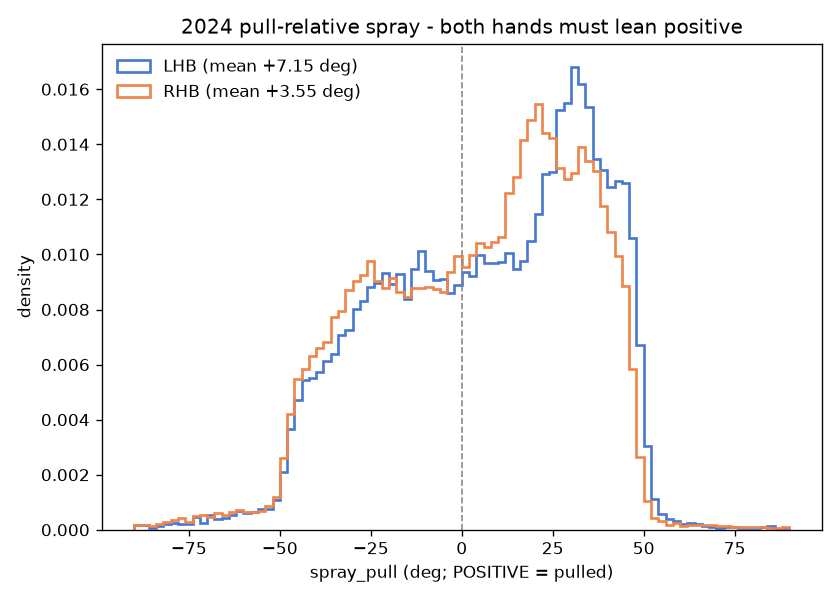

*Mean spray_pull by batter, split by handedness — positive is pulled. Both hands centre well right of zero, mirrored as intended.*

In [4]:
show_fig("stage2_rebuild/figures/spray_by_hand.png",
         caption="Mean spray_pull by batter, split by handedness — positive is pulled. Both hands centre well right of zero, mirrored as intended.")

And a second, independent sanity check in *raw* (unmirrored) coordinates: home runs should cluster to each hand's pull field. What to look for: the HR density leaning to opposite sides for L and R — the raw geometry is right before any mirroring folds it onto one axis.

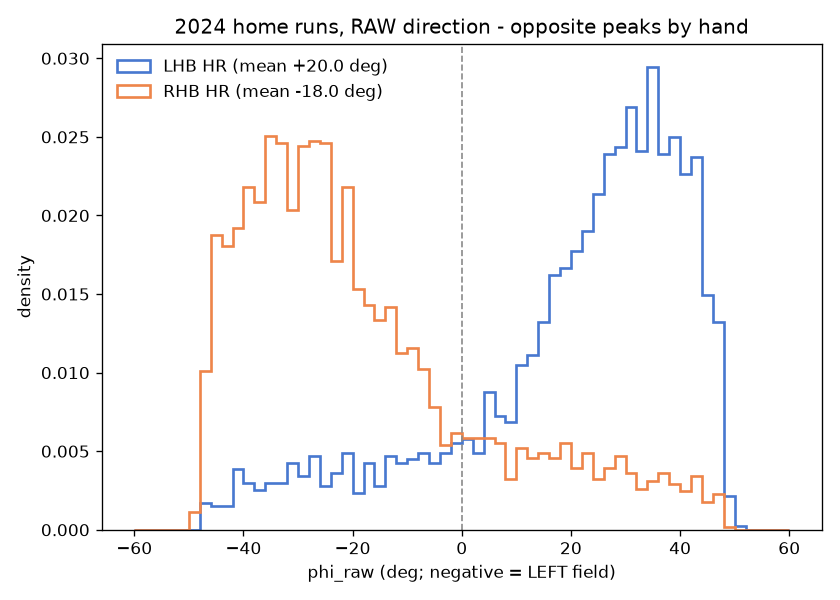

*Home-run spray in raw field direction — LHB pull to right field, RHB to left. The mirror in spray_pull folds these onto one axis.*

In [5]:
show_fig("stage2_rebuild/figures/spray_hr_raw_direction.png",
         caption="Home-run spray in raw field direction — LHB pull to right field, RHB to left. The mirror in spray_pull folds these onto one axis.")

## The ruler is calibrated — now, how fine are its gradations?

The inputs are sound. Before I read a spray result off them, one more question, and it is the one that makes or breaks the whole notebook: **how reproducible is a BART fit?** pymc-bart 0.12 draws its trees stochastically, and — this surprised me — the fit is *not* reproducible across processes even at a fixed seed. So "the model got better" only means something relative to how much the *same model* moves when you just run it again.

I measured that two ways. Three identical Stage-A smoke fits (same seed, same data, same code) spread **556 nats** in held-out log-likelihood. And a full Stage-C replicate of the *v0 anchor itself* — same three features, same everything — landed **+267.1 nats above** the frozen anchor (−79,840.4 vs −80,107.5). That +267 is the noise floor: any spray ELPD gain smaller than it is indistinguishable from just rerunning v0.

(These two figures are the one place in this notebook without a committed JSON — there is no persisted metrics file for the replicate or the Stage-A triple, so they are quoted from `results/RESULTS.md` §"Sampler reproducibility" and hard-coded below with a comment. The anchor itself *is* committed.)

In [6]:
# prose-only: no committed metrics.json for the replicate or the Stage-A triple.
# Source: results/RESULTS.md section "Sampler reproducibility". The anchor below IS committed.
STAGE_A_SPREAD = 556.0        # nats, spread of three identical Stage-A fits
ELPD_REPLICATE = -79840.4     # nats, full Stage-C replicate of the v0 anchor
elpd_anchor = v0["elpd"]["elpd_lppd"]           # committed: results/stage_C/metrics.json
noise_floor = ELPD_REPLICATE - elpd_anchor       # +267.1: the same model, run twice
Markdown(f"**Noise floor:** two runs of the *same* v0 model differ by **{noise_floor:+.1f} nats** "
         f"({round(ELPD_REPLICATE, 1)} replicate vs {round(elpd_anchor, 1)} anchor), and the Stage-A "
         f"triple spans **{STAGE_A_SPREAD:.0f} nats**. Any spray ELPD gain below ~{noise_floor:.0f} is invisible against this.")

**Noise floor:** two runs of the *same* v0 model differ by **+267.1 nats** (-79840.4 replicate vs -80107.5 anchor), and the Stage-A triple spans **556 nats**. Any spray ELPD gain below ~267 is invisible against this.

## The refit: spray goes in, the likelihood doesn't move

Now the actual experiment — Stage C, five features, the same 100k batted balls, scored against the same held-out events as the anchor. Three ways to read it, and all three say the same thing.

**Held-out likelihood (the pre-registered gate, E1).** The spray model's ELPD is **−79,876.3**. That is +231.2 above the anchor — but +231 is *inside* the +267 noise floor, and against the same-session replicate it is actually **−35.9**, i.e. slightly *worse*. A gain smaller than the run-to-run wobble is not a gain. **E1 fails.**

What to look for below: the spray row's improvement over the anchor (+231.2) comes in *under* what the identical-model replicate scored (+267.1) — exactly where "no real change" would put it.

In [7]:
elpd_spray = sp["elpd"]["elpd_lppd"]             # committed: results/stage_C_spray/metrics.json
pl.DataFrame([
    {"run": "v0 anchor (frozen)",     "features": 3, "ELPD": round(elpd_anchor, 1),   "delta vs anchor": "—"},
    {"run": "v0 replicate (same 3)",   "features": 3, "ELPD": round(ELPD_REPLICATE, 1), "delta vs anchor": f"{ELPD_REPLICATE - elpd_anchor:+.1f}"},
    {"run": "spray (5 features)",      "features": 5, "ELPD": round(elpd_spray, 1),    "delta vs anchor": f"{elpd_spray - elpd_anchor:+.1f}"},
])

run,features,ELPD,delta vs anchor
"""v0 anchor (frozen)""",3,-80107.5,"""—"""
"""v0 replicate (same 3)""",3,-79840.4,"""+267.1"""
"""spray (5 features)""",5,-79876.3,"""+231.2"""


**Calibration (E2) and replication.** The other two reads point the same way. Calibration got *worse*: expected-calibration error **0.0531** for the spray model vs **0.0422** for v0. And the model reproduces Savant *less* faithfully, not more — the event-level correlation drops to **0.873** (from **0.911**) and the player-level to **0.908** (from **0.956**). **E2 fails too.**

In [8]:
pl.DataFrame([
    {"metric": "calibration ECE (lower is better)", "v0 anchor": round(v0["calibration"]["ece_weighted"], 4),
     "spray": round(sp["calibration"]["ece_weighted"], 4)},
    {"metric": "event-level r vs Savant", "v0 anchor": round(v0["replication"]["event_r_holdout"], 3),
     "spray": round(sp["replication"]["event_r_holdout"], 3)},
    {"metric": "player-level r vs Savant", "v0 anchor": round(v0["replication"]["player_r_holdout"], 3),
     "spray": round(sp["replication"]["player_r_holdout"], 3)},
])

metric,v0 anchor,spray
"""calibration ECE (lower is bett…",0.0422,0.0531
"""event-level r vs Savant""",0.911,0.873
"""player-level r vs Savant""",0.956,0.908


## Here's the twist: it *did* learn spray

The tidy story would be "spray is noise, the model ignored it." That is not what happened. In the model's own variable-importance ranking, `spray_pull` comes in **third of five** — ahead of both raw handedness (`stand_R`) and sprint speed. The model reached for it. It just couldn't turn it into held-out accuracy.

What to look for: the importance order below, with `spray_pull` sitting mid-pack, not at the bottom.

In [9]:
labels = sp["variable_importance"]["feature_labels"]
order = sp["variable_importance"]["raw"]["indices"]
pl.DataFrame([{"rank": i + 1, "feature": labels[idx]} for i, idx in enumerate(order)])

rank,feature
1,"""launch_angle"""
2,"""launch_speed"""
3,"""spray_pull"""
4,"""stand_R"""
5,"""sprint_speed"""


And you can see *what* it learned. The partial-dependence surface for home-run probability rises steadily as contact moves from the opposite field to the pull side. What to look for: P(HR) climbing from about **0.20** on the oppo side to **0.37** at roughly +40° of pull (at the launch angle where homers live) — a real, physically sensible gradient the model found on its own.

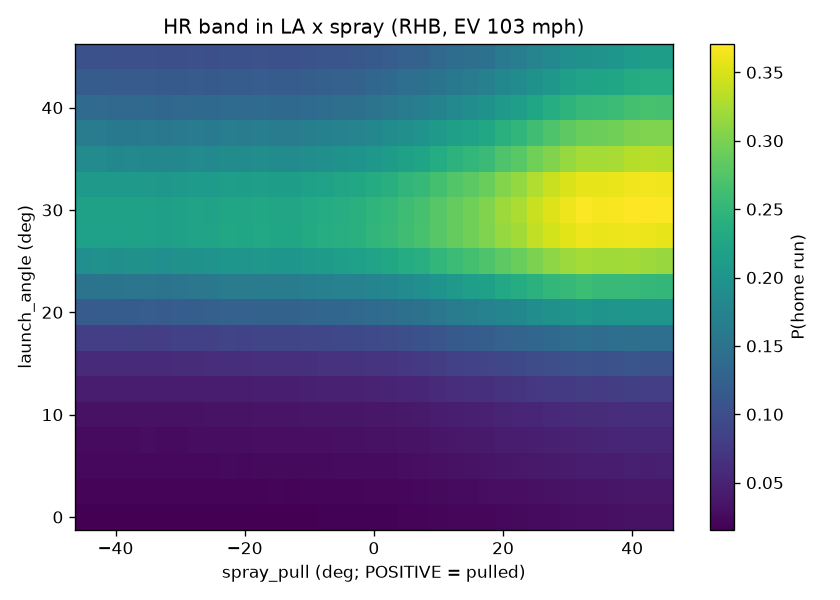

*P(home run) across launch angle and spray — peak 0.37 at LA 30 deg, spray +40 deg (pull). Pulled contact in the air is the home-run zone — and the model learned it.*

In [10]:
show_fig("stage_C_spray/figures/pdp_la_spray_hr.png",
         caption=f"P(home run) across launch angle and spray — peak {sp['pdp_hr_band']['max_p_hr']:.2f} at "
                 f"LA {sp['pdp_hr_band']['argmax_la']:.0f} deg, spray +{sp['pdp_hr_band']['argmax_spray']:.0f} deg (pull). "
                 f"Pulled contact in the air is the home-run zone — and the model learned it.")

### Two things I'm deliberately *not* reading too hard

Honesty about a negative cuts both ways — a couple of numbers in this stage look like signal and aren't.

- **The reliability figure is stale.** `stage_C_spray/figures/calibration_reliability.png` is still the old 1×5-strip render, so I am letting the ECE number (0.0531 vs 0.0422) carry the calibration story rather than show a misleading picture.
- **Don't over-read the localization slope (E7).** The spray model's sprint-localization curves are computed on a *pulled-grounder* grid, which is not the same object as v0's, so the two aren't comparable. And the slope itself moved from ~0.0023 to ~0.0010 between two *identical* runs — a wobble bigger than any effect it could be measuring. It is noise, not a finding.

## One last place to look: conditioning the season rollup on spray

Maybe the event surface is the wrong place. Even if per-ball P(outcome) doesn't sharpen, perhaps *using* each ball's spray when rolling up to a player-season would help predict next season. So I ran the A/B directly: roll up **marginalized** over spray vs **conditioned** on it, and score next-season prediction.

Conditioning is reliably *counter*productive. Marginalized beats conditioned in **6 of 7** band/pair splits, and a paired bootstrap over players puts the calibrated-RMSE gap at **+0.000317** [+0.000189, +0.000458] — with the conditioned rollup winning **0 of 5,000** resamples. Reliable, but tiny: the gap is well under the 0.001 practical bar. And the column that actually matters is the last one — **both** spray rollups lose to plain v0 in every band.

What to look for: v0 (and Savant) sitting at or below both spray variants.

In [11]:
def rmse3(block):   # calibrated RMSE, scaled to x10^-3
    return round(ra["pooled_pa30"][block]["rmse_calibrated"] * 1000, 2)
pb = ra["paired_bootstrap_pa30"]["delta_rmse_calibrated"]
display(pl.DataFrame([
    {"rollup (PA>=30)": "conditioned on spray",    "calibrated RMSE x10^-3": rmse3("xwoba_conditioned")},
    {"rollup (PA>=30)": "marginalized over spray", "calibrated RMSE x10^-3": rmse3("xwoba_marginalized")},
    {"rollup (PA>=30)": "v0 (no spray)",           "calibrated RMSE x10^-3": rmse3("xwoba_v0")},
    {"rollup (PA>=30)": "Savant",                  "calibrated RMSE x10^-3": rmse3("xwoba_savant")},
]))
Markdown(f"**Conditioned − marginalized:** +{ra['verdict']['delta_rmse_pa30_cond_minus_marg']:.6f} calibrated RMSE, "
         f"95% CI [+{pb['ci95'][0]:.6f}, +{pb['ci95'][1]:.6f}], conditioned better in "
         f"{pb['frac_better']:.0%} of {ra['paired_bootstrap_pa30']['n_reps']:,} resamples — reliable, and reliably the "
         f"wrong direction, but far under the 0.001 bar that would make it matter.")

rollup (PA>=30),calibrated RMSE x10^-3
"""conditioned on spray""",36.59
"""marginalized over spray""",36.27
"""v0 (no spray)""",35.82
"""Savant""",35.56


**Conditioned − marginalized:** +0.000317 calibrated RMSE, 95% CI [+0.000189, +0.000458], conditioned better in 0% of 5,000 resamples — reliable, and reliably the wrong direction, but far under the 0.001 bar that would make it matter.

By PA band, the same picture. What to look for: the two spray rollups tracking *above* v0 (worse) across the whole range — adding spray to the rollup never helps.

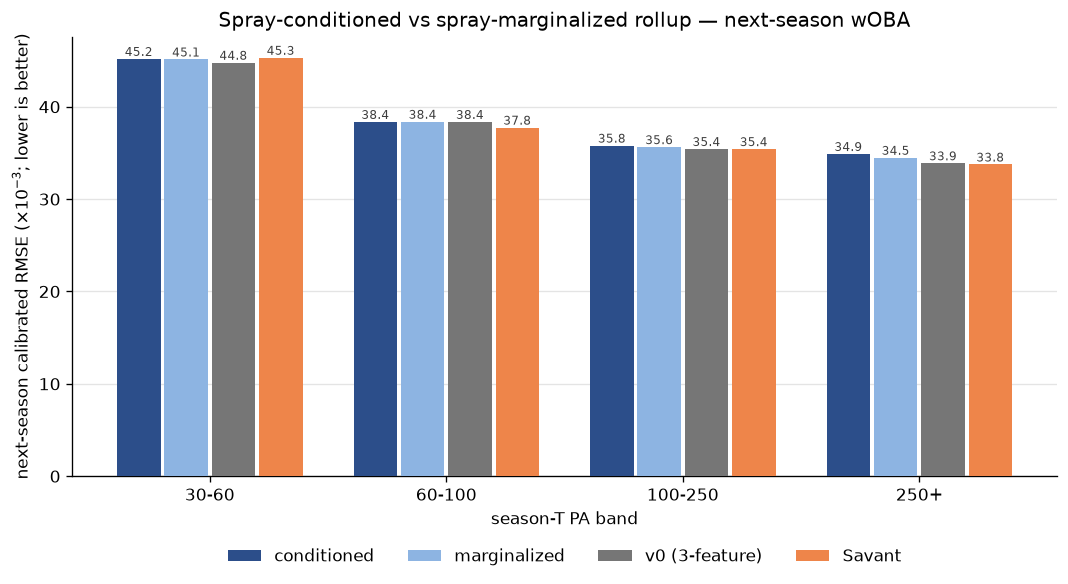

*Next-season xwOBA RMSE by PA band — conditioned and marginalized spray rollups vs v0 and Savant. v0 sits at or below both spray variants everywhere.*

In [12]:
show_fig("rollup_ab/figures/next_season_rmse_by_band.png",
         caption="Next-season xwOBA RMSE by PA band — conditioned and marginalized spray rollups vs v0 and Savant. v0 sits at or below both spray variants everywhere.")

## Reading it: capacity dilution, not missing information

Put the three layers together and a consistent story falls out. The inputs are clean and correctly signed. The model *reaches* for spray (importance #3) and learns a sensible pulled-air home-run gradient. And yet held-out likelihood, calibration, replication and the downstream rollup all say: no gain, or a small loss.

My reading is **capacity dilution, not missing information**. The same fixed budget — 50 trees — now has to cover five features instead of three, so the marginal detail spray adds comes at the cost of resolution on the three features that were already carrying the prediction. That is a *testable* hypothesis, not a hand-wave: `scripts/capacity_experiment.py` re-fits Stage C with the tree budget raised to 200 and compares held-out likelihood per event, paired. It is written and smoke-tested — but it has **not** been run at Stage C yet (≈5.3 h of compute), so I am listing it as the open question, not a result.

## Where this leaves things

The spray surface stalled — but it stalled *honestly*. Measured against a run-to-run noise floor, with a sign-checked ruler, the verdict is clear: three features already sit at the information ceiling Part 2 found, and a fifth doesn't move held-out accuracy even though the model happily learns from it. The wall from Part 2 is still standing. Whether more tree capacity brings it down is the one thread left hanging.

So while the *surface* went nowhere, the more interesting move was to change the **question**. Every notebook so far has asked "how good is this hitter's number for the season that just happened?" Part 7 asks a different one: stand at a hitter's first few dozen plate appearances and **forecast the rest of his season** — with a calibrated range that tightens as the games play out. That is where the project actually moved forward.

Full write-ups: `results/stage2_rebuild/NOTES.md`, `results/rollup_ab/NOTES.md`, and `results/RESULTS.md`.

In [13]:
# guard: the numbers quoted in the prose above vs the artifacts — fails loudly on drift.
# (The two noise-floor figures — 556 nats, replicate -79,840.4 / +267.1 — have no committed
#  JSON; they are quoted from RESULTS.md and not asserted here. Everything else is committed.)
assert all(g["pass"] for g in rb["gates"]) and [g["name"][:2] for g in rb["gates"]] == ["R1", "R2", "R3", "R4", "R5", "R6"]
assert all(rb["before"][y]["digest"] == rb["after"][y]["digest"] for y in ("2022", "2023", "2024", "2025"))  # R2 byte-identical
assert all(g["pass"] for g in qc["gates"])
assert round(min(qc["per_season"][y]["mean_pull"]["L"] for y in ("2022", "2023", "2024", "2025")), 2) == 6.84
assert round(max(qc["per_season"][y]["mean_pull"]["L"] for y in ("2022", "2023", "2024", "2025")), 2) == 7.50
assert round(min(qc["per_season"][y]["mean_pull"]["R"] for y in ("2022", "2023", "2024", "2025")), 2) == 3.23
assert round(max(qc["per_season"][y]["mean_pull"]["R"] for y in ("2022", "2023", "2024", "2025")), 2) == 3.62
assert round(qc["named_2024"]["Kyle Schwarber"]["mean_pull"], 2) == 13.90
assert round(qc["named_2024"]["Ryan Mountcastle"]["mean_pull"], 2) == -5.16
assert qc["n_switch_2024"] == 65
_sw = {s["stand"]: s for s in qc["switch_by_stand"]}
assert round(_sw["L"]["mean_pull"], 2) == 8.68 and round(_sw["R"]["mean_pull"], 2) == 5.60
# the refit vs the committed anchor
assert round(sp["elpd"]["elpd_lppd"], 1) == -79876.3 and round(v0["elpd"]["elpd_lppd"], 1) == -80107.5
assert round(sp["elpd"]["elpd_lppd"] - v0["elpd"]["elpd_lppd"], 1) == 231.2   # inside the +267 floor
assert round(sp["calibration"]["ece_weighted"], 4) == 0.0531 and round(v0["calibration"]["ece_weighted"], 4) == 0.0422
assert round(sp["replication"]["event_r_holdout"], 3) == 0.873 and round(v0["replication"]["event_r_holdout"], 3) == 0.911
assert round(sp["replication"]["player_r_holdout"], 3) == 0.908 and round(v0["replication"]["player_r_holdout"], 3) == 0.956
assert sp["variable_importance"]["raw"]["indices"] == [1, 0, 2, 3, 4]         # spray_pull ranks #3 of 5
assert sp["variable_importance"]["feature_labels"][2] == "spray_pull"
assert round(sp["pdp_hr_band"]["max_p_hr"], 2) == 0.37
# rollup A/B
assert round(ra["pooled_pa30"]["xwoba_conditioned"]["rmse_calibrated"] * 1000, 2) == 36.59
assert round(ra["pooled_pa30"]["xwoba_marginalized"]["rmse_calibrated"] * 1000, 2) == 36.27
assert round(ra["pooled_pa30"]["xwoba_v0"]["rmse_calibrated"] * 1000, 2) == 35.82
assert round(ra["pooled_pa30"]["xwoba_savant"]["rmse_calibrated"] * 1000, 2) == 35.56
_splits = ra["by_band"] + ra["by_pair"]
_marg_wins = sum(s["xwoba_marginalized"]["rmse_calibrated"] < s["xwoba_conditioned"]["rmse_calibrated"] for s in _splits)
assert _marg_wins == 6 and len(_splits) == 7                                  # "6 of 7 splits"
assert round(ra["verdict"]["delta_rmse_pa30_cond_minus_marg"], 6) == 0.000317
_ci = ra["paired_bootstrap_pa30"]["delta_rmse_calibrated"]["ci95"]
assert round(_ci[0], 6) == 0.000189 and round(_ci[1], 6) == 0.000458
assert ra["paired_bootstrap_pa30"]["delta_rmse_calibrated"]["frac_better"] == 0.0
print("prose numbers still match the artifacts")

prose numbers still match the artifacts
